Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None, 'use_bn': False, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'sgd', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'rmsprop', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'xavier', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': 'l1', 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': 'l2', 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.5}


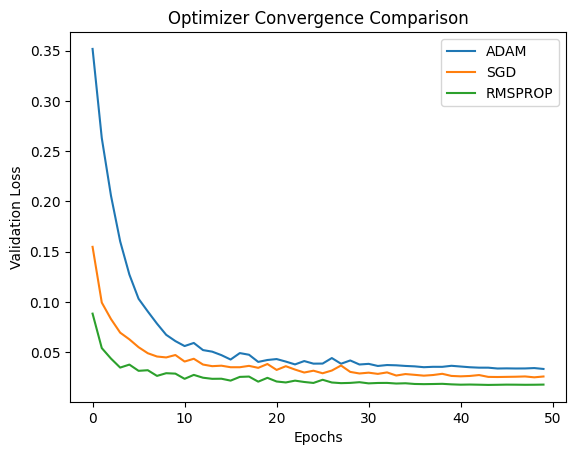

,CV_RMSE,Optimizer,Init,Reg,BatchNorm,Dropout
6,8.167839e+05,adam,he,l2,True,0.0
4,8.368104e+05,adam,xavier,None,True,0.0
2,8.813677e+05,adam,he,None,True,0.0
5,8.867136e+05,adam,he,l1,True,0.0
3,8.948154e+05,rmsprop,he,None,True,0.0
0,9.116896e+05,adam,he,None,False,0.0
1,1.078555e+06,sgd,he,None,True,0.0
7,2.089398e+06,adam,he,None,True,0.5


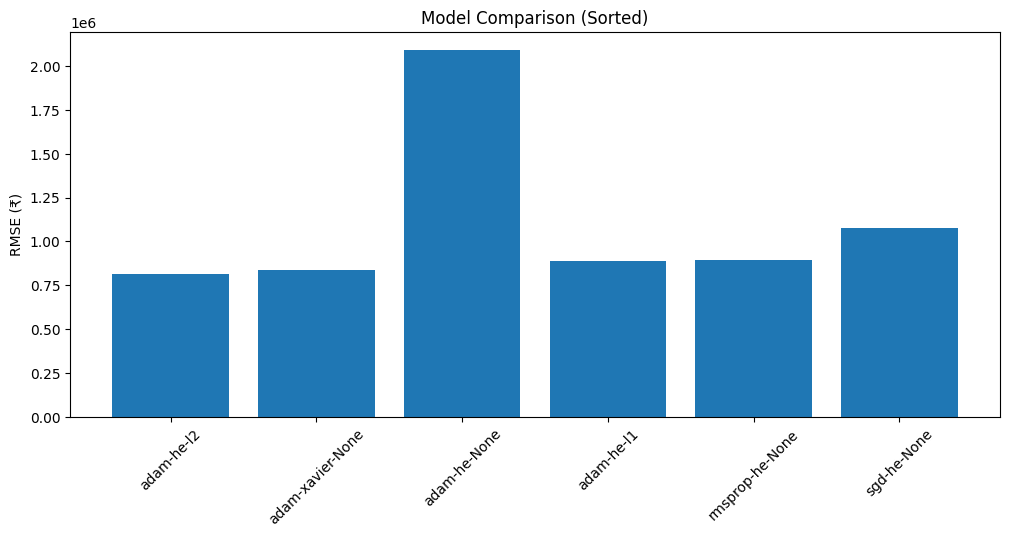


===== BEST CONFIGURATION =====
optimizer_name: adam
init_type: he
regularizer_type: l2
use_bn: True
dropout_rate: 0.0
CV RMSE: 816783.87
Epoch 1/50
375/375 [==============================] - 1s 1ms/step - loss: 0.5582
Epoch 2/50
375/375 [==============================] - 0s 1ms/step - loss: 0.3919
Epoch 3/50
375/375 [==============================] - 0s 1ms/step - loss: 0.3187
Epoch 4/50
375/375 [==============================] - 0s 1ms/step - loss: 0.2544
Epoch 5/50
375/375 [==============================] - 0s 1ms/step - loss: 0.2085
Epoch 6/50
375/375 [==============================] - 0s 1ms/step - loss: 0.1715
Epoch 7/50
375/375 [==============================] - 0s 1ms/step - loss: 0.1414
Epoch 8/50
375/375 [==============================] - 0s 1ms/step - loss: 0.1270
Epoch 9/50
375/375 [==============================] - 0s 1ms/step - loss: 0.1058
Epoch 10/50
375/375 [==============================] - 1s 1ms/step - loss: 0.0998
Epoch 11/50
375/375 [==============================

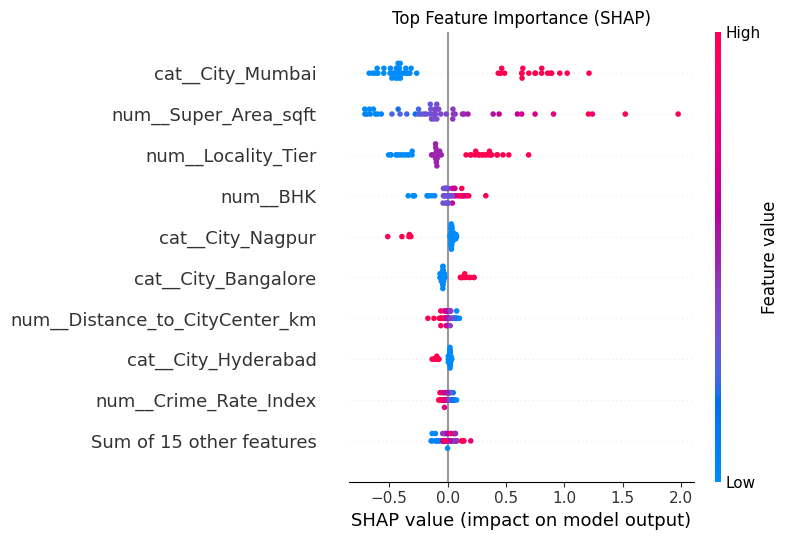

In [1]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.initializers import GlorotUniform, HeNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau

import joblib
import shap
from IPython.display import display

np.random.seed(42)
tf.random.set_seed(42)

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("house_price_dataset_india_12k.csv")
df.columns = df.columns.str.strip()
df = df.drop(columns=["House_ID", "Price_per_sqft_INR"], errors="ignore")

X = df.drop("Market_Price_INR", axis=1)
y = df["Market_Price_INR"]



lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)



# =========================
# 3. PREPROCESSING
# =========================
categorical_nominal = ["City", "Furnishing"]

locality_map = {"Budget": 0, "Mid": 1, "Premium": 2}
X["Locality_Tier"] = X["Locality_Tier"].map(locality_map)

numerical_cols = [col for col in X.columns if col not in categorical_nominal]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_nominal)
])

y_scaler = StandardScaler()

# =========================
# 4. MODEL BUILDER
# =========================
def build_model(config):
    initializer = HeNormal(seed=np.random.randint(10000)) if config["init_type"] == "he" else GlorotUniform(seed=np.random.randint(10000))

    reg = None
    if config["regularizer_type"] == "l1":
        reg = l1(0.001)
    elif config["regularizer_type"] == "l2":
        reg = l2(0.001)

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, kernel_initializer=initializer, kernel_regularizer=reg),
        BatchNormalization() if config["use_bn"] else tf.keras.layers.Activation("linear"),
        tf.keras.layers.ReLU(),
        Dropout(config["dropout_rate"]) if config["dropout_rate"] > 0 else tf.keras.layers.Activation("linear"),

        Dense(64, kernel_initializer=initializer, kernel_regularizer=reg),
        BatchNormalization() if config["use_bn"] else tf.keras.layers.Activation("linear"),
        tf.keras.layers.ReLU(),
        Dropout(config["dropout_rate"]) if config["dropout_rate"] > 0 else tf.keras.layers.Activation("linear"),

        Dense(32),
        tf.keras.layers.ReLU(),
        Dense(1)
    ])

    if config["optimizer_name"] == "sgd":
        optimizer = SGD(learning_rate=0.001, momentum=0.9)
    elif config["optimizer_name"] == "rmsprop":
        optimizer = RMSprop(learning_rate=0.0005)
    else:
        optimizer = Adam(learning_rate=0.001)

    model.compile(optimizer=optimizer, loss="mse")
    return model

# =========================
# 5. EXPERIMENT CONFIG
# =========================
experiments = [
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None, "use_bn": False, "dropout_rate": 0.0},
    {"optimizer_name": "sgd", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "rmsprop", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "xavier", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": "l1", "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": "l2", "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.5},
]

# =========================
# 6. CROSS VALIDATION
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
first_history = None
histories = {}

for config in experiments:
    print("Running:", config)
    fold_rmse = []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_tr = preprocessor.fit_transform(X_tr)
        X_val = preprocessor.transform(X_val)

        global input_dim
        input_dim = X_tr.shape[1]

        y_tr_scaled = y_scaler.fit_transform(y_tr.values.reshape(-1,1))
        y_val_scaled = y_scaler.transform(y_val.values.reshape(-1,1))

        model = build_model(config)

        history = model.fit(
            X_tr, y_tr_scaled,
            validation_data=(X_val, y_val_scaled),
            epochs=50, batch_size=32, verbose=0,
            callbacks=[lr_scheduler]
        )

        opt_name = config["optimizer_name"]

        if opt_name not in histories:
            histories[opt_name] = []

        histories[opt_name].append(history.history['val_loss'])

        # Save first history ONLY
        if first_history is None:
            first_history = history

        preds = model.predict(X_val, verbose=0)
        preds = y_scaler.inverse_transform(preds)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_rmse.append(rmse)

    results.append({
        "config": config,
        "CV_RMSE": np.mean(fold_rmse)
    })

# =========================
# 7. CONVERGENCE PLOT (FIXED POSITION)
# =========================
plt.figure()

for opt, hists in histories.items():
    avg = np.mean(hists, axis=0)
    plt.plot(avg, label=opt.upper())

plt.legend()
plt.title("Optimizer Convergence Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.show()

# =========================
# 8. RESULTS DISPLAY
# =========================
results_df = pd.DataFrame(results).sort_values(by="CV_RMSE")

expanded = results_df.copy()
expanded["Optimizer"] = expanded["config"].apply(lambda x: x["optimizer_name"])
expanded["Init"] = expanded["config"].apply(lambda x: x["init_type"])
expanded["Reg"] = expanded["config"].apply(lambda x: x["regularizer_type"] if x["regularizer_type"] else "None")
expanded["BatchNorm"] = expanded["config"].apply(lambda x: x["use_bn"])
expanded["Dropout"] = expanded["config"].apply(lambda x: x["dropout_rate"])
expanded = expanded.drop(columns=["config"])

display(expanded)

# =========================
# 9. BETTER BAR PLOT
# =========================
expanded_sorted = expanded.sort_values(by="CV_RMSE")

labels = expanded_sorted.apply(
    lambda x: f"{x['Optimizer']}-{x['Init']}-{x['Reg']}",
    axis=1
)

plt.figure(figsize=(12,5))
plt.bar(labels, expanded_sorted["CV_RMSE"])
plt.xticks(rotation=45)
plt.ylabel("RMSE (₹)")
plt.title("Model Comparison (Sorted)")
plt.show()

# =========================
# 10. BEST MODEL
# =========================
best_config = results_df.iloc[0]["config"]
best_rmse = results_df.iloc[0]["CV_RMSE"]

print("\n===== BEST CONFIGURATION =====")
for k, v in best_config.items():
    print(f"{k}: {v}")
print(f"CV RMSE: {best_rmse:.2f}")

# =========================
# 11. FINAL TRAINING
# =========================
X_processed = preprocessor.fit_transform(X)
input_dim = X_processed.shape[1]

y_scaled = y_scaler.fit_transform(y.values.reshape(-1,1))

best_model = build_model(best_config)
best_model.fit(X_processed, y_scaled, epochs=50, batch_size=32, verbose=1)



# =========================
# 12. SAVE
# =========================
best_model.save("model/best_model.keras")
joblib.dump(preprocessor, "model/scaler.pkl")
joblib.dump(y_scaler, "model/y_scaler.pkl")

with open("model/metrics.json", "w") as f:
    json.dump({"rmse": float(best_rmse)}, f)

# =========================
# 13. SHAP (SIMPLIFIED & CLEAN)
# =========================

import shap

# Use SMALL sample
sample_np = X_processed[:50]

# Extract Feature names
feature_names = preprocessor.get_feature_names_out()

# Create Explainer and calculate SHAP values (with silent=True!)
explainer = shap.Explainer(best_model.predict, sample_np)
shap_values = explainer(sample_np, silent=True)

# ---------------------------------------------------------
# THE FIX: Tell SHAP what the feature names are
shap_values.feature_names = list(feature_names)
# ---------------------------------------------------------

# Plot ONLY top features
plt.figure(figsize=(10,6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)

plt.title("Top Feature Importance (SHAP)")
plt.tight_layout()
plt.show()